# CSDR API Examples: DEP Mangroves

This notebook follows the same end-to-end API flow as `sdf_public_api_demo.ipynb`, but reuses the `api_get` / `get_items` pattern from `API_Examples.ipynb` and lets `geopandas` handle geometry conversion, joins, reprojection, and mapping.

Target product:
- Dataset: `Digital Earth Pacific Mangrove Extents`
- Geometries: `Pacific Exclusive Economic Zones`
- Product: `Digital Earth Pacific Mangrove Extents per Pacific Exclusive Economic Zones`

In [1]:
import os
import subprocess
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display
from shapely.geometry import shape

try:
    import folium  # noqa: F401
    import mapclassify  # noqa: F401
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "folium", "mapclassify"]
    )

APP_BASE_URL = os.getenv("CSDR_APP_BASE_URL", "https://csdr.dev.oceandevelopmentdata.org")
API_BASE_URL = os.getenv("CSDR_API_BASE_URL", f"{APP_BASE_URL}/api/v0")
AUTH_BASE_URL = f"{APP_BASE_URL}/api/auth"
API_KEY = os.getenv("CSDR_API_KEY") or os.getenv("CSDR_CLOUD_SPATIAL_APP_API_KEY")

TARGET_DATASET_NAME = "Digital Earth Pacific Mangrove Extents"
TARGET_GEOMETRY_NAME = "Pacific Exclusive Economic Zones"
TARGET_PRODUCT_NAME = "Digital Earth Pacific Mangrove Extents per Pacific Exclusive Economic Zones"
PACIFIC_PROJECTION = "+proj=robin +lon_0=180 +datum=WGS84 +units=m +no_defs"

session = requests.Session()
session.headers.update({"Accept": "application/json"})

In [2]:
def auth_post(path: str, payload: dict | None = None) -> dict:
    url = f"{AUTH_BASE_URL.rstrip('/')}/{path.lstrip('/')}"
    response = session.post(url, json=payload or {}, timeout=60)
    response.raise_for_status()
    return response.json()


def api_get(path: str, params: dict | None = None, headers: dict | None = None) -> dict:
    url = f"{API_BASE_URL.rstrip('/')}/{path.lstrip('/')}"
    response = session.get(url, headers=headers, params=params, timeout=60)
    response.raise_for_status()

    payload = response.json()
    if "data" not in payload:
        raise ValueError(f"API response missing 'data' field: {response.text}")

    return payload["data"]


def get_items(path: str, params: dict | None = None, headers: dict | None = None):
    query = dict(params or {})
    page = int(query.get("page", 1))
    query.setdefault("size", 50)

    while True:
        query["page"] = page
        page_payload = api_get(path, query, headers=headers)

        page_count = int(page_payload.get("pageCount", 1))
        rows = page_payload.get("data", [])
        yield from rows

        if page >= page_count:
            break

        page += 1

In [3]:
if API_KEY:
    session.headers["x-api-key"] = API_KEY
    auth_mode = "x-api-key header"
else:
    anonymous = auth_post("/sign-in/anonymous")
    auth_mode = f"anonymous session cookie ({anonymous['user']['id']})"

print("App base:", APP_BASE_URL)
print("API base:", API_BASE_URL)
print("Auth mode:", auth_mode)

App base: https://csdr.dev.oceandevelopmentdata.org
API base: https://csdr.dev.oceandevelopmentdata.org/api/v0
Auth mode: anonymous session cookie (4zPHNhzeaDUMI1TxZiAsbcbAIdhSoZEq)


## Discover the dataset, geometry collection, and matching product

In [4]:
datasets_df = pd.DataFrame(list(get_items("/dataset", params={"size": 100})))
geometries_df = pd.DataFrame(list(get_items("/geometries", params={"size": 100})))

display(datasets_df[["id", "name", "mainRunId", "createdAt"]])
display(geometries_df[["id", "name", "mainRunId", "createdAt"]])

dataset_row = datasets_df.loc[datasets_df["name"] == TARGET_DATASET_NAME].iloc[0]
geometry_row = geometries_df.loc[geometries_df["name"] == TARGET_GEOMETRY_NAME].iloc[0]

products_df = pd.DataFrame(
    list(
        get_items(
            "/product",
            params={
                "datasetId": dataset_row["id"],
                "geometriesId": geometry_row["id"],
                "size": 100,
            },
        )
    )
)

display(products_df[["id", "name", "mainRunId", "timePrecision", "createdAt"]])

,id,name,mainRunId,createdAt
0,9ddda9fc-8d74-4f3d-867c-0d01eaf1e1e7,Digital Earth Pacific Mangrove Extents,d26792f8-2857-4f1d-bb52-2cfe6f05b437,2026-02-24T01:22:39.095Z
1,fd0a5b43-a9d4-4e5c-893b-4f6ac71dc9cd,VIDA Buildings,32203ddf-9249-45f5-a67d-9439b1a8306c,2025-12-16T04:58:30.336Z
2,6486daff-aea2-4bee-b39f-57b82f5c25df,Geoscience Australia Sentinel-2 Coastal Ecosys...,3c3b2dff-9936-4ec6-912c-95e12b379a52,2025-12-12T01:06:51.222Z
3,f3749ab0-ecf1-4b88-8a3d-893fefb9e1cb,Allen Coral Atlas Reef Extents,873a8788-7e4d-4fe9-85c2-ab66a1345b88,2025-12-03T05:37:27.254Z
4,9b6875d2-f897-42a7-9923-ee6995e2d90f,Digital Earth Pacific Seagrass Extents,8d8cbcce-4279-45c2-8ab5-3d5cc690add3,2025-11-25T04:29:56.977Z
5,fc10b123-98ce-45de-974e-b667679506b4,Global Mangrove Watch v3,bb9db2d8-76f8-4e0f-80e8-8dff744e54d2,2025-10-19T23:14:32.126Z
6,5714917f-3549-4a95-9fc4-ff96efbdf311,Global Mangrove Watch v4,5f79eb3c-bd0c-4fff-8f4d-09490689aacb,2025-10-09T07:45:49.196Z


,id,name,mainRunId,createdAt
0,3f13c68c-3655-44c9-89d6-74852cb18fa1,Pacific Exclusive Economic Zones,dbceb6d7-f6c4-5cdf-9faa-728a78caea5a,2026-02-25T01:59:23.617Z
1,9d27aaae-7d25-4315-9604-2c83e2010c3f,Australian Bureau of Statistics - Australian S...,51cfaf9e-0518-5b0b-b6a3-b63bef9f381b,2025-12-17T22:40:48.863Z
2,d00ea16b-bc0b-4487-afe1-e8ab72e55991,A test (for WKB),8ccbdcd8-67a9-4756-a634-561ff630e6bd,2025-12-17T05:17:36.448Z
3,0650d638-7351-47f7-ae6f-efa9a9db1aa3,GA Coastal Waters Areas,4d3ee1b8-285b-5c78-b62c-bb08f0abe637,2025-12-12T04:48:04.037Z
4,b1bc53d1-e5b2-4532-a029-d131bbe29fdb,Australian Coastal Sediment Compartments - Sec...,47ab8a00-9d9f-5618-bfd2-772261184023,2025-12-11T01:22:33.311Z
5,abs-asgs-2021-sa2,ABS ASGS 2021 - Statistical Area 2,abs-asgs-2021-sa2-geojson-import-1,2025-12-03T02:59:41.390Z
6,9120a989-8207-47ea-bb11-be76b69ddbf0,Global Exclusive Economic Zones,1cad60fb-73d3-5f95-a733-6bde395af587,2025-10-09T08:27:32.563Z


,id,name,mainRunId,timePrecision,createdAt
0,5e7cd722-9534-4378-aedb-d5471d8af95a,Digital Earth Pacific Mangrove Extents per Pac...,10cbd732-72a7-593f-a464-84615400b761,year,2026-02-25T04:19:27.487Z


In [5]:
product_row = products_df.loc[products_df["name"] == TARGET_PRODUCT_NAME].iloc[0]

dataset_detail = api_get(f"/dataset/{dataset_row['id']}")
geometry_detail = api_get(f"/geometries/{geometry_row['id']}")
product_detail = api_get(f"/product/{product_row['id']}")

dataset_run = dataset_detail["mainRun"]
geometry_run = geometry_detail["mainRun"]
product_run = product_detail["mainRun"]
indicator_entries = (product_run.get("outputSummary") or {}).get("indicators") or []
product_indicator = (
    indicator_entries[0].get("indicator")
    if indicator_entries
    else {"name": "Mangrove Area", "unit": "m²"}
)

display(
    pd.Series(
        {
            "dataset": dataset_detail["name"],
            "dataset_run_id": dataset_run["id"],
            "dataset_data_type": dataset_run.get("dataType"),
            "dataset_data_url": dataset_run.get("dataUrl"),
            "dataset_source_metadata_url": (dataset_run.get("provenanceJson") or {}).get("sourceMetadataUrl"),
            "geometries": geometry_detail["name"],
            "geometries_run_id": geometry_run["id"],
            "geometries_data_url": geometry_run.get("dataUrl"),
            "product": product_detail["name"],
            "product_run_id": product_run["id"],
            "product_data_url": product_run.get("dataUrl"),
            "time_precision": product_detail["timePrecision"],
            "indicator": product_indicator.get("name"),
            "indicator_unit": product_indicator.get("unit"),
        }
    )
)

dataset                                   Digital Earth Pacific Mangrove Extents
dataset_run_id                              d26792f8-2857-4f1d-bb52-2cfe6f05b437
dataset_data_type                                                stac-geoparquet
dataset_data_url               s3://csdr-public-dev/datasets/dep-mangrove/0-0...
dataset_source_metadata_url    https://data.digitalearthpacific.org/#dep_s2_m...
geometries                                      Pacific Exclusive Economic Zones
geometries_run_id                           dbceb6d7-f6c4-5cdf-9faa-728a78caea5a
geometries_data_url            s3://csdr-public-dev/geometries/eez-pacific/0-...
product                        Digital Earth Pacific Mangrove Extents per Pac...
product_run_id                              10cbd732-72a7-593f-a464-84615400b761
product_data_url               s3://csdr-public-dev/products/dep-mangrove-eez...
time_precision                                                              year
indicator                   

## Export and summarise the product outputs

In [6]:
records = list(get_items(f"/product-run/{product_run['id']}/outputs/export", params={"size": 1000}))
df = pd.DataFrame(records)

df["timePoint"] = pd.to_datetime(df["timePoint"], utc=True)
df["year"] = df["timePoint"].dt.year

indicator_unit = product_indicator.get("unit") or "m²"
value_scale = 1_000_000 if indicator_unit == "m²" else 1
display_unit = "km²" if indicator_unit == "m²" else indicator_unit

df["value_display"] = df["value"] / value_scale
df = df.sort_values(["timePoint", "geometryOutputName"]).reset_index(drop=True)

display(
    pd.Series(
        {
            "rows": len(df),
            "time_start": df["timePoint"].min(),
            "time_end": df["timePoint"].max(),
            "years": sorted(df["year"].unique().tolist()),
            "geometry_count": df["geometryOutputId"].nunique(),
            "display_unit": display_unit,
            "latest_total": round(
                df.loc[df["year"] == df["year"].max(), "value_display"].sum(),
                3,
            ),
        }
    )
)

rows                                                           216
time_start                               2017-01-01 00:00:00+00:00
time_end                                 2024-01-01 00:00:00+00:00
years             [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
geometry_count                                                  27
display_unit                                                   km²
latest_total                                              6156.101
dtype: object

In [7]:
latest_year = int(df["year"].max())

latest = (
    df.loc[df["year"] == latest_year, ["geometryOutputName", "indicatorName", "value_display"]]
    .sort_values("value_display", ascending=False)
    .head(10)
    .rename(
        columns={
            "geometryOutputName": "geography",
            "indicatorName": "indicator",
            "value_display": f"value ({display_unit})",
        }
    )
    .reset_index(drop=True)
)

latest

,geography,indicator,value (km²)
0,Papua New Guinea,Mangrove Area,4609.4655
1,Solomon Islands,Mangrove Area,548.8111
2,Fiji,Mangrove Area,494.0604
3,New Caledonia,Mangrove Area,319.5440
4,Micronesia,Mangrove Area,90.7248
5,Palau,Mangrove Area,59.1230
6,Vanuatu,Mangrove Area,15.9812
7,Tonga,Mangrove Area,11.1416
8,Samoa,Mangrove Area,2.4090
9,Gilbert Islands,Mangrove Area,1.5906


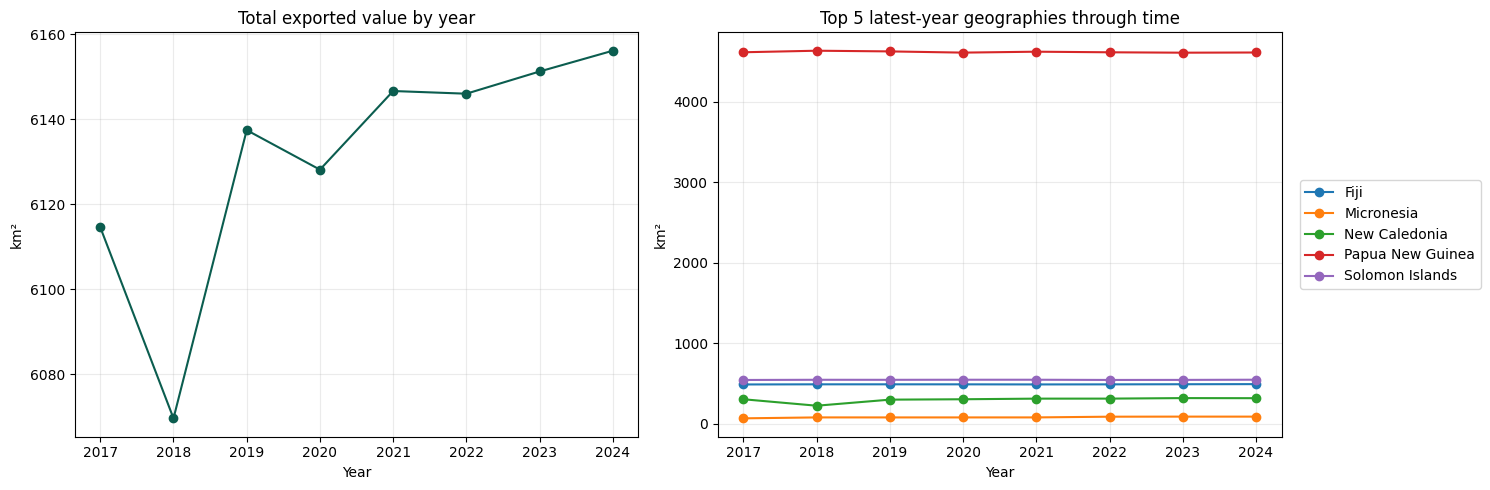

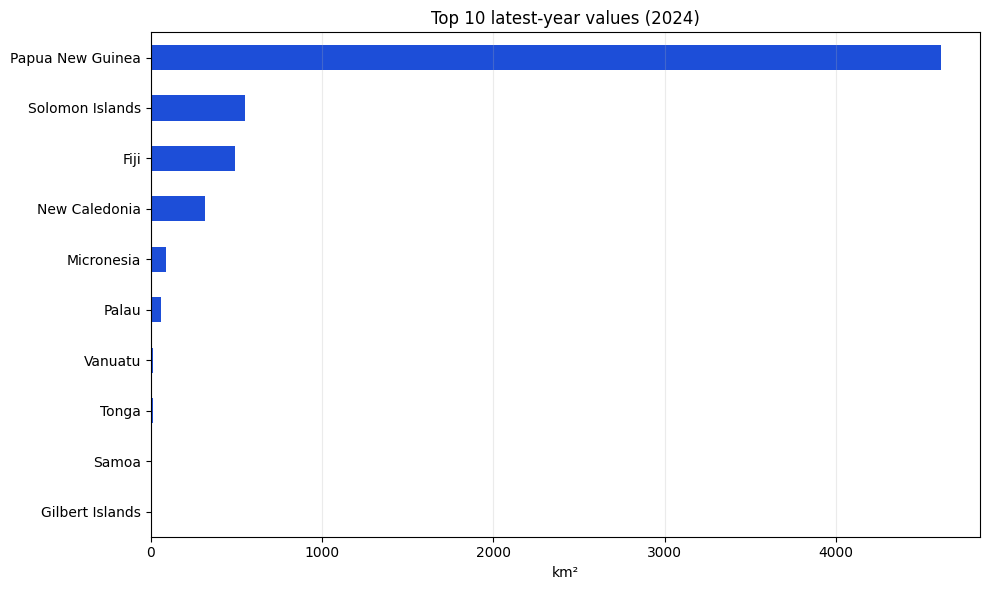

In [8]:
annual_totals = df.groupby("year", as_index=False)["value_display"].sum()
top_geographies = latest["geography"].head(5).tolist()
top_series = (
    df[df["geometryOutputName"].isin(top_geographies)]
    .pivot(index="year", columns="geometryOutputName", values="value_display")
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    annual_totals["year"],
    annual_totals["value_display"],
    marker="o",
    color="#0b5d4f",
)
axes[0].set_title("Total exported value by year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel(display_unit)
axes[0].grid(alpha=0.25)

for geography in top_series.columns:
    axes[1].plot(top_series.index, top_series[geography], marker="o", label=geography)
axes[1].set_title("Top 5 latest-year geographies through time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel(display_unit)
axes[1].grid(alpha=0.25)
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
value_column = f"value ({display_unit})"
latest.sort_values(value_column).plot.barh(
    x="geography",
    y=value_column,
    ax=ax,
    color="#1d4ed8",
    legend=False,
)
ax.set_title(f"Top 10 latest-year values ({latest_year})")
ax.set_xlabel(display_unit)
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Join the latest values back to the geometry outputs

In [9]:
geometry_outputs = list(
    get_items(f"/geometries-run/{product_run['geometriesRun']['id']}/outputs/export", params={"size": 1000})
)

geometry_rows = [
    {
        "id": item.get("id"),
        "name": item.get("name"),
        **(item.get("properties") or {}),
        "geometry": shape(item["geometry"]),
    }
    for item in geometry_outputs
]

gdf = gpd.GeoDataFrame(geometry_rows, geometry="geometry", crs="EPSG:4326")

latest_rows = df.loc[
    df["year"] == latest_year,
    ["geometryOutputId", "geometryOutputName", "indicatorName", "value_display"],
].copy()
latest_rows["value_label"] = latest_rows["value_display"].map(
    lambda value: f"{value:,.2f} {display_unit}"
)

map_gdf = gdf.merge(latest_rows, how="left", left_on="id", right_on="geometryOutputId")
map_gdf = map_gdf.rename(columns={"name": "geography"})

display(
    map_gdf[
        [
            "geography",
            "indicatorName",
            "value_display",
            "value_label",
            "geometry",
        ]
    ].sort_values("value_display", ascending=False)
    .head(10)
)

,geography,indicatorName,value_display,value_label,geometry
10,Papua New Guinea,Mangrove Area,4609.4655,"4,609.47 km²","MULTIPOLYGON (((151.42405 1.62572, 151.42312 1..."
13,Solomon Islands,Mangrove Area,548.8111,548.81 km²,"MULTIPOLYGON (((163.06402 -5.03192, 163.13397 ..."
4,Fiji,Mangrove Area,494.0604,494.06 km²,"MULTIPOLYGON (((-178.53742 -15.26711, -178.523..."
12,New Caledonia,Mangrove Area,319.5440,319.54 km²,"MULTIPOLYGON (((170.20617 -22.89716, 170.21841..."
9,Micronesia,Mangrove Area,90.7248,90.72 km²,"MULTIPOLYGON (((148.0688 11.65078, 148.08218 1..."
26,Palau,Mangrove Area,59.1230,59.12 km²,"MULTIPOLYGON (((134.86814 11.55063, 134.91782 ..."
7,Vanuatu,Mangrove Area,15.9812,15.98 km²,"MULTIPOLYGON (((166.9111 -12.43636, 166.92681 ..."
8,Tonga,Mangrove Area,11.1416,11.14 km²,"MULTIPOLYGON (((-171.84753 -15.87838, -171.801..."
18,Samoa,Mangrove Area,2.4090,2.41 km²,"MULTIPOLYGON (((-173.77469 -11.04813, -173.755..."
16,Gilbert Islands,Mangrove Area,1.5906,1.59 km²,"MULTIPOLYGON (((-180 -1.58287, -179.9962 -1.59..."


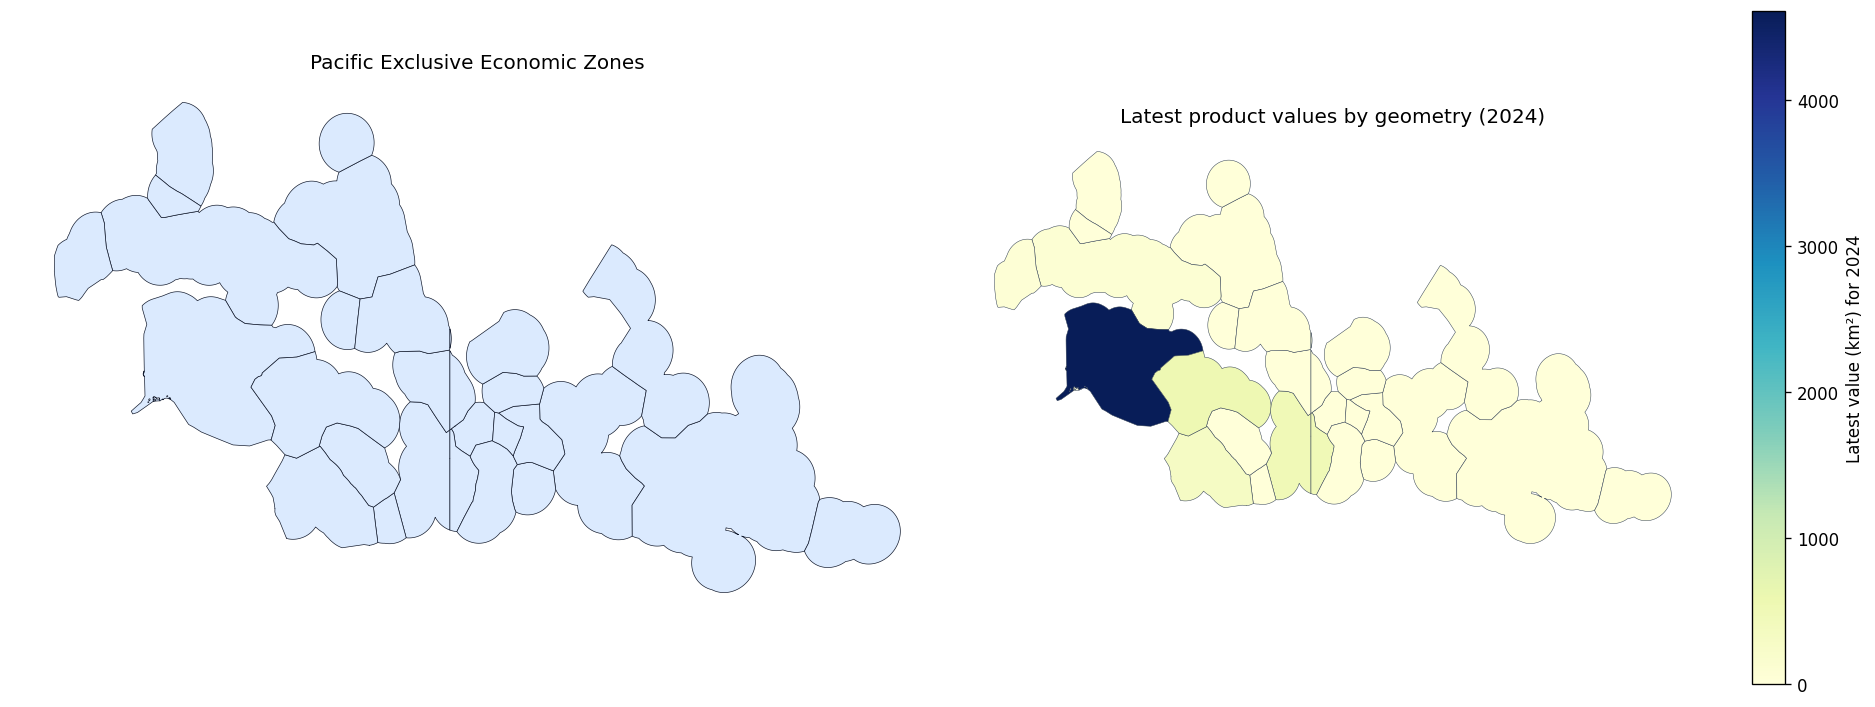

In [10]:
pacific_gdf = map_gdf.to_crs(PACIFIC_PROJECTION)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

pacific_gdf.plot(
    ax=axes[0],
    facecolor="#dbeafe",
    edgecolor="#0f172a",
    linewidth=0.4,
)
axes[0].set_title(geometry_detail["name"])
axes[0].set_axis_off()

pacific_gdf.plot(
    column="value_display",
    ax=axes[1],
    cmap="YlGnBu",
    legend=True,
    linewidth=0.3,
    edgecolor="#334155",
    missing_kwds={
        "color": "#e5e7eb",
        "edgecolor": "#334155",
        "label": "No latest value",
    },
    legend_kwds={"label": f"Latest value ({display_unit}) for {latest_year}"},
)
axes[1].set_title(f"Latest product values by geometry ({latest_year})")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
outline_map = map_gdf[["geography", "geometry"]].explore(
    tooltip=["geography"],
    tiles="CartoDB positron",
    style_kwds={
        "color": "#0f172a",
        "weight": 1,
        "fillColor": "#60a5fa",
        "fillOpacity": 0.12,
    },
)
outline_map

In [ ]:
latest_value_map = map_gdf.explore(
    column="value_display",
    tooltip=["geography", "value_label", "indicatorName"],
    popup=["geography", "value_label", "indicatorName"],
    tiles="CartoDB positron",
    cmap="YlGnBu",
    legend=True,
    style_kwds={
        "color": "#334155",
        "weight": 1,
        "fillOpacity": 0.75,
    },
    legend_kwds={"caption": f"Latest value ({display_unit}) for {latest_year}"},
)
latest_value_map